## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# Mengatur tampilan agar semua kolom terlihat
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import.")

Library berhasil di-import.


## 2. Load Data & Cleaning

In [2]:
# Membaca dataset
df = pd.read_csv('data-bank.csv')

# Membersihkan spasi di awal/akhir nama kolom
df.columns = df.columns.str.strip()

print("Dimensi data:", df.shape)
print("\nContoh nama kolom setelah dibersihkan:")
print(df.columns[:5].tolist())

# Cek ketidakseimbangan target
target_count = df['Bankrupt?'].value_counts()
print("\nDistribusi Kelas (0=Sehat, 1=Bangkrut):")
print(target_count)
print(f"Rasio Bangkrut: {target_count[1] / len(df) * 100:.2f}%")

Dimensi data: (6819, 96)

Contoh nama kolom setelah dibersihkan:
['Bankrupt?', 'ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Operating Gross Margin']

Distribusi Kelas (0=Sehat, 1=Bangkrut):
Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Rasio Bangkrut: 3.23%


## 3. Pre-Processing

In [3]:
# Memisahkan Fitur (X) dan Target (y)
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

# Split Data (80% Training, 20% Testing)
# stratify=y memastikan rasio bangkrut di data train & test tetap sama
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nData Training: {X_train.shape}")
print(f"Data Testing: {X_test.shape}")


Data Training: (5455, 95)
Data Testing: (1364, 95)


## 4. Modeling (Random Forest)

In [4]:
# Menggunakan class_weight='balanced' untuk mengatasi data yang tidak seimbang
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # KUNCI UTAMA: Memberi bobot lebih pada kelas minoritas
    n_jobs=-1
)

print("\nSedang melatih model...")
rf_model.fit(X_train, y_train)
print("Pelatihan selesai.")


Sedang melatih model...
Pelatihan selesai.


## 5. Evaluasi Model


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.82      0.20      0.33        44

    accuracy                           0.97      1364
   macro avg       0.90      0.60      0.66      1364
weighted avg       0.97      0.97      0.96      1364


=== ROC AUC SCORE ===
Score: 0.9238


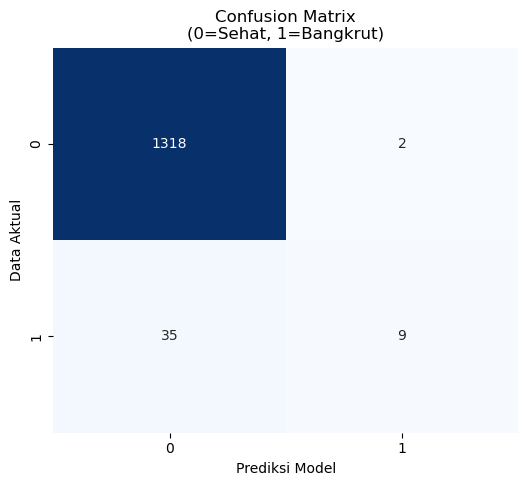

In [5]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("\n=== ROC AUC SCORE ===")
# Skor mendekati 1.0 berarti model sangat bagus membedakan bangkrut vs sehat
print(f"Score: {roc_auc_score(y_test, y_prob):.4f}")

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix\n(0=Sehat, 1=Bangkrut)')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.show()

## 6. Feature Importance


=== TOP 10 INDIKATOR Pengaruh ===
1. Borrowing dependency (0.0511)
2. Net Income to Total Assets (0.0452)
3. Persistent EPS in the Last Four Seasons (0.0404)
4. Total debt/Total net worth (0.0385)
5. Continuous interest rate (after tax) (0.0383)
6. Retained Earnings to Total Assets (0.0367)
7. Total income/Total expense (0.0333)
8. Liability to Equity (0.0304)
9. Net worth/Assets (0.0289)
10. After-tax net Interest Rate (0.0268)


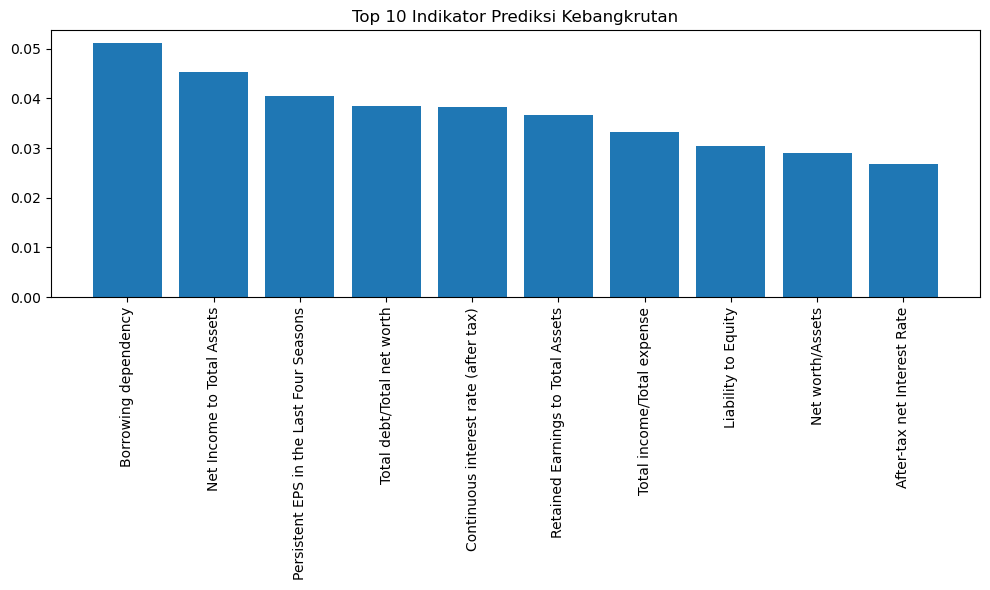

In [6]:
# Melihat indikator keuangan apa yang paling mempengaruhi kebangkrutan
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n=== TOP 10 INDIKATOR Pengaruh ===")
for i in range(10):
    print(f"{i+1}. {X.columns[indices[i]]} ({importances[indices[i]]:.4f})")

plt.figure(figsize=(10, 6))
plt.title("Top 10 Indikator Prediksi Kebangkrutan")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), X.columns[indices[:10]], rotation=90)
plt.tight_layout()
plt.show()